[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yzyouzhang/dafx2026-hrtf-tutorial/blob/main/01_minimal_neural_field.ipynb)

<!-- TODO: "main" is a placeholder branch -- re-point to a release tag (e.g. v1.0-dafx26) closer to the tutorial date -->


In [ ]:
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import os

    REPO_NAME = "dafx2026-hrtf-tutorial"
    REPO_URL = "https://github.com/yzyouzhang/dafx2026-hrtf-tutorial.git"
    BRANCH = "main"  # TODO: placeholder branch -- re-point to a release tag (e.g. v1.0-dafx26) closer to the tutorial date

    if os.path.basename(os.getcwd()) != REPO_NAME:
        if not os.path.isdir(REPO_NAME):
            !git clone -b {BRANCH} {REPO_URL}
        %cd {REPO_NAME}

    if os.path.exists("requirements.txt"):
        !pip install -q -r requirements.txt
    else:
        print("WARNING: requirements.txt not found at repo root -- dependencies were not installed; install manually.")

# 01 — Minimal Neural Field for HRTF Modeling

**DAFx 2026 Tutorial: From Neural Fields to Personalized Spatial Audio**
Neil Zhang & Yoshiki Masuyama

This notebook builds a minimal neural field for HRTFs following the actual [HRTF Field](https://github.com/yzyouzhang/hrtf_field) formulation (Zhang, Wang, Duan, ICASSP 2023):

- A **SIREN** (sinusoidal-activation MLP) maps direction → HRTF magnitude spectrum, as a continuous function rather than a lookup table tied to the measurement grid.
- For multiple subjects, a per-subject **latent code is inferred by a single gradient step from zero** (a gradient-origin / auto-decoder trick), rather than a fixed embedding table — this means the same mechanism works for subjects seen during training *and* for genuinely unseen subjects, using only a small support set of their measured directions. This personalization mechanism is the thread that continues through `03_upsampling_ranf.ipynb`'s retrieval augmentation.

Two parts:
1. **Single-subject field**: fit one subject's HRTF with no latent — the simplest version of the formulation, as a warm-up.
2. **Multi-subject field with inferred latents**: shared SIREN decoder + gradient-inferred per-subject codes, evaluated on both held-out *directions* and held-out *subjects*.

Runs on CPU by default (`FAST` config); a `FULL` config is provided for GPU. See also this open pedagogical notebook covering the same territory: [AcousticsML 5.3](https://github.com/RAMshades/AcousticsML), companion to Bianco et al., *"Machine Learning in Acoustics: A Review and Open-source Repository,"* npj Acoustics 2025.

## 0. Setup: device, CPU/GPU config

In [1]:
import os
import glob
import copy

import numpy as np
import torch
import torch.nn as nn
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from src.data import load_real_sonicom_dir, synthesize_sonicom_like, hrir_to_log_mag

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SOFA_DIR = "data/sonicom"   # directory of p0001.sofa .. p0030.sofa

CONFIGS = {
    "FAST": dict(
        # hidden_dim=512 is still 4x below the original HRTF Field's 2048 (see train.py),
        # but the original's 128 was ~256x smaller in the dominant weight matrix -- too
        # narrow for a SIREN to represent the widened frequency range in Section 7.
        hidden_dim=512, n_layers=3, w0=30.0, latent_dim=8,
        # 162 bins * (48000/512) Hz/bin =~ 15.1 kHz -- one bin past the pinna-notch band
        # (5-11 kHz) instead of cutting off at ~4.5 kHz; SONICOM's fs=48000, not 44100.
        n_freq_bins=162, n_epochs=300, lr=5e-4, weight_decay=1e-3,
        batch_size=18,  # subject mini-batch size, matching train.py's default
        lr_decay=0.01,  # Keras-style LR decay rate, matching train.py's default
        n_train_subjects=20, n_val_subjects=5, n_test_subjects=5,
        support_frac=0.2,   # fraction of directions used to infer z (the "sparse measurement")
    ),
    "FULL": dict(
        hidden_dim=2048, n_layers=3, w0=30.0, latent_dim=32,
        n_freq_bins=162, n_epochs=2000, lr=5e-4, weight_decay=1e-3,
        batch_size=18, lr_decay=0.01,
        n_train_subjects=None, n_val_subjects=10, n_test_subjects=10,
        support_frac=0.2,
    ),
}

# TODO(neil): flip to "FULL" once running on GPU with a larger subject pool
ACTIVE_CONFIG = "FAST"
cfg = CONFIGS[ACTIVE_CONFIG]
print(f"Active config: {ACTIVE_CONFIG} -> {cfg}")

/Users/zhangyou036/anaconda3/envs/dafx-hrtf/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Active config: FAST -> {'hidden_dim': 512, 'n_layers': 3, 'w0': 30.0, 'latent_dim': 8, 'n_freq_bins': 162, 'n_epochs': 300, 'lr': 0.0005, 'weight_decay': 0.001, 'batch_size': 18, 'lr_decay': 0.01, 'n_train_subjects': 20, 'n_val_subjects': 5, 'n_test_subjects': 5, 'support_frac': 0.2}


## 1. Load data (shared loader from `src/data.py`, same as notebook 00)

In [2]:
if SOFA_DIR and os.path.isdir(SOFA_DIR) and glob.glob(os.path.join(SOFA_DIR, "*.sofa")):
    hrir, positions, subject_ids, fs = load_real_sonicom_dir(SOFA_DIR)
    print(f"Loaded {hrir.shape[0]} real SONICOM subjects from '{SOFA_DIR}/'.")
else:
    hrir, positions, subject_ids, fs = synthesize_sonicom_like(n_subjects=12)
    print("Using synthetic placeholder data — drop real .sofa files in data/ for the real thing.")

print("hrir shape:", hrir.shape, "(subjects, directions, ears, taps)")

SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription

SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel


SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription

SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel


SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
Loaded 30 real SONICOM subjects from 'data/sonicom/'.
hrir shape: (30, 828, 2, 256) (subjects, directions, ears, taps)


## 2. Preprocess: HRIR → log-magnitude spectra, direction encoding

**A note on training domain.** The three papers this tutorial builds on don't all train in the same domain, and it's worth being explicit about that rather than picking one silently:

- **HRTF Field** (Zhang, Wang, Duan 2023) trains on **linear-scale magnitude** with plain MSE (their Eq. 4).
- **NIIRF** (Masuyama et al. 2024) and **RANF** (Masuyama et al. 2025) both train directly on a **log-spectral-distortion (LSD) loss** — squared `20·log₁₀(pred/true)` — which is mathematically identical to plain MSE computed directly on dB-scale values, since `20·log₁₀(pred/true) = dB(pred) − dB(true)`.

The two domains are not equivalent in what they optimize: linear-magnitude MSE weights loud spectral peaks heavily (a peak twice as tall contributes ~4x the squared error) and can under-fit quiet spectral notches; dB-domain training weights peaks and notches roughly equally in relative terms, which matters because notches carry localization-relevant cues. This is a real trade-off, not just an implementation detail.

**We use dB-domain training here**, matching NIIRF and RANF, since notebooks 02–03 build on that convention.

In [3]:
n_dir = hrir.shape[1]
log_mag = hrir_to_log_mag(hrir, cfg["n_freq_bins"])   # [n_subj, n_dir, 2, n_freq_bins], dB

# Direction input: azimuth/elevation in radians, scaled to roughly [-1, 1]
dir_feats = np.stack([
    np.deg2rad(positions[:, 0]) / np.pi,
    np.deg2rad(positions[:, 1]) / np.pi,
], axis=-1).astype(np.float32)   # [n_dir, 2]

# z-score normalize dB values for stable SIREN training (a constant rescaling of the
# squared-log-ratio / LSD loss used by NIIRF and RANF — same objective, better-scaled gradients)
mag_mean, mag_std = log_mag.mean(), log_mag.std()
log_mag_norm = (log_mag - mag_mean) / mag_std

dir_feats_t = torch.tensor(dir_feats, device=device)
log_mag_t = torch.tensor(log_mag_norm, dtype=torch.float32, device=device)  # [n_subj, n_dir, 2, F]

print("dir_feats:", dir_feats_t.shape, " log_mag (normalized dB):", log_mag_t.shape)

dir_feats: torch.Size([828, 2])  log_mag (normalized dB): torch.Size([30, 828, 2, 162])


## 3. SIREN layers (as in HRTF Field / Sitzmann et al. 2020)

In [4]:
class SirenLayer(nn.Module):
    def __init__(self, in_f, out_f, w0=30.0, is_first=False, is_last=False):
        super().__init__()
        self.w0 = w0
        self.linear = nn.Linear(in_f, out_f)
        self.is_last = is_last
        b = 1 / in_f if is_first else np.sqrt(6 / in_f) / w0
        with torch.no_grad():
            self.linear.weight.uniform_(-b, b)

    def forward(self, x):
        x = self.linear(x)
        return x if self.is_last else torch.sin(self.w0 * x)


def build_siren(dims, w0):
    layers = [SirenLayer(dims[0], dims[1], w0=w0, is_first=True)]
    for d0, d1 in zip(dims[1:-2], dims[2:-1]):
        layers.append(SirenLayer(d0, d1, w0=w0))
    layers.append(SirenLayer(dims[-2], dims[-1], w0=w0, is_last=True))
    return nn.Sequential(*layers)

## 4. Single-subject field (warm-up, no latent)

Fit one subject's full HRTF with a SIREN — direction in, magnitude spectrum out, nothing else. This is the simplest version of the formulation: proof that a small MLP can represent a subject's entire directional HRTF as one continuous function.


Warm-up fit (single subject):   0%|          | 0/100 [00:00<?, ?it/s]


Warm-up fit (single subject):   0%|          | 0/100 [00:00<?, ?it/s, loss=1]


Warm-up fit (single subject):  15%|█▌        | 15/100 [00:00<00:00, 141.68it/s, loss=1]


Warm-up fit (single subject):  15%|█▌        | 15/100 [00:00<00:00, 141.68it/s, loss=0.115]


Warm-up fit (single subject):  34%|███▍      | 34/100 [00:00<00:00, 168.56it/s, loss=0.115]

...


Warm-up fit (single subject):  54%|█████▍    | 54/100 [00:00<00:00, 178.98it/s, loss=0.0415]


Warm-up fit (single subject):  73%|███████▎  | 73/100 [00:00<00:00, 179.66it/s, loss=0.0415]


Warm-up fit (single subject):  73%|███████▎  | 73/100 [00:00<00:00, 179.66it/s, loss=0.0341]


Warm-up fit (single subject):  91%|█████████ | 91/100 [00:00<00:00, 176.23it/s, loss=0.0341]


Warm-up fit (single subject): 100%|██████████| 100/100 [00:00<00:00, 174.48it/s, loss=0.0341]

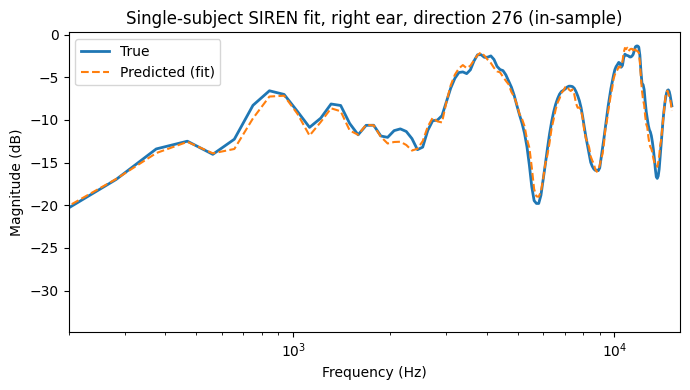

This direction was seen during fitting — this just confirms the SIREN can represent the signal at all.


In [5]:
warmup_subject = 0
dims = [2] + [cfg["hidden_dim"] for _ in range(cfg["n_layers"] - 1)] + [2 * cfg["n_freq_bins"]]
warmup_net = build_siren(dims, cfg["w0"]).to(device)

target = log_mag_t[warmup_subject].reshape(n_dir, -1)  # [n_dir, 2*F], normalized dB
optimizer = torch.optim.Adam(warmup_net.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])

warmup_epochs = max(50, cfg["n_epochs"] // 3)
pbar = tqdm(range(warmup_epochs), desc="Warm-up fit (single subject)")
for epoch in pbar:
    pred = warmup_net(dir_feats_t)
    loss = nn.functional.mse_loss(pred, target)  # dB-domain MSE == squared LSD, matching NIIRF/RANF
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % max(1, warmup_epochs // 5) == 0:
        pbar.set_postfix(loss=loss.item())

with torch.no_grad():
    pred_db = (warmup_net(dir_feats_t).cpu().numpy().reshape(n_dir, 2, -1) * mag_std + mag_mean)
true_db = log_mag[warmup_subject]

example_dir = n_dir // 3
freqs = np.fft.rfftfreq(512, d=1 / fs)[:cfg["n_freq_bins"]]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(freqs, true_db[example_dir, 1], label="True", linewidth=2)
ax.plot(freqs, pred_db[example_dir, 1], label="Predicted (fit)", linestyle="--")
ax.set_xscale("log"); ax.set_xlim(200, 16000)
ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Magnitude (dB)")
ax.set_title(f"Single-subject SIREN fit, right ear, direction {example_dir} (in-sample)")
ax.legend()
plt.tight_layout()
plt.show()
print("This direction was seen during fitting — this just confirms the SIREN can represent the signal at all.")

## 5. Multi-subject field with gradient-inferred latents

Now the real setup: a shared SIREN decoder takes `[direction, latent z]`. For any subject (training or held-out), `z` is inferred from a small **support set** of that subject's measured directions with a single gradient step from zero — no embedding table, no separate encoder network needed. This is trained jointly with the decoder for training subjects, and applied as-is (network frozen) for held-out subjects.

Three details below now match the original [HRTF Field training script](https://github.com/yzyouzhang/hrtf_field/blob/main/train.py) rather than a simplified stand-in:
- **`create_graph=True`** on the z-inference gradient: the outer backward pass differentiates *through* the inner gradient-origin step into the decoder's weights (true bi-level/IGON training), not just through the resulting z treated as a fixed input.
- **Subject mini-batching**: gradients are accumulated over a batch of subjects (`batch_size=18`, matching `train.py`) before each optimizer step, instead of stepping after every single subject.
- **Keras-style LR decay** (`lr_i = lr0 / (1 + 0.01·i)` per epoch), matching `train.py`'s schedule, instead of a flat learning rate.

In [6]:
latent_dim = cfg["latent_dim"]
dims_multi = [2 + latent_dim] + [cfg["hidden_dim"] for _ in range(cfg["n_layers"] - 1)] + [2 * cfg["n_freq_bins"]]
field = build_siren(dims_multi, cfg["w0"]).to(device)

def forward_field(dirs, z):
    # dirs: [n_pts, 2], z: [n_pts, latent_dim] (already broadcast to match dirs)
    x = torch.cat([dirs, z], dim=-1)
    return field(x)

def infer_latent(support_dirs, support_targets, create_graph=False):
    """Single gradient-origin step: z = -grad(loss at z=0).
    create_graph=True reproduces the original HRTF Field / IGON training procedure exactly
    (train.py: torch.autograd.grad(..., create_graph=True, retain_graph=True)): gradients
    flow through this inner step back into the decoder's weights during the OUTER backward
    pass, so the decoder is trained to be good at *being* gradient-origin-inferred -- a true
    bi-level/meta-learning objective, not just at fitting whatever z happens to fall out of a
    frozen inference step. Used with create_graph=True during training (below) and left at
    the cheaper create_graph=False by default here for evaluation, where the decoder is
    frozen and no outer backward pass will touch it -- same z either way, less compute."""
    z0 = torch.zeros(1, latent_dim, device=device, requires_grad=True)
    z0_rep = z0.repeat(support_dirs.shape[0], 1)
    pred = forward_field(support_dirs, z0_rep)
    loss = nn.functional.mse_loss(pred, support_targets)
    grad = torch.autograd.grad(loss, [z0], create_graph=create_graph, retain_graph=create_graph)[0]
    return -grad  # [1, latent_dim]

def subject_losses(dirs, targets, support_idx, query_idx, create_graph=False):
    support_dirs, support_targets = dirs[support_idx], targets[support_idx]
    query_dirs, query_targets = dirs[query_idx], targets[query_idx]
    z = infer_latent(support_dirs, support_targets, create_graph=create_graph)
    z_rep = z.repeat(query_dirs.shape[0], 1)
    pred = forward_field(query_dirs, z_rep)
    loss = nn.functional.mse_loss(pred, query_targets)
    return loss, pred, query_targets

n_subjects = hrir.shape[0]
n_test = min(cfg["n_test_subjects"], n_subjects)
n_val = min(cfg["n_val_subjects"], n_subjects - n_test)
n_train = cfg["n_train_subjects"] if cfg["n_train_subjects"] is not None else n_subjects - n_val - n_test
n_train = min(n_train, n_subjects - n_val - n_test)

train_subject_idx = np.arange(n_train)
val_subject_idx = np.arange(n_train, n_train + n_val)
test_subject_idx = np.arange(n_train + n_val, n_train + n_val + n_test)
print(f"{len(train_subject_idx)} training subjects, {len(val_subject_idx)} validation subjects, {len(test_subject_idx)} test subjects")

rng = np.random.default_rng(0)
n_support = max(1, int(cfg["support_frac"] * n_dir))
support_idx = rng.choice(n_dir, size=n_support, replace=False)
query_idx = np.setdiff1d(np.arange(n_dir), support_idx)
print(f"{n_support} support directions (used to infer z) / {len(query_idx)} query directions per subject")

20 training subjects, 5 validation subjects, 5 test subjects
165 support directions (used to infer z) / 663 query directions per subject



Training (multi-subject, latent-inferred):   0%|          | 0/300 [00:00<?, ?it/s]


Training (multi-subject, latent-inferred):   0%|          | 0/300 [00:00<?, ?it/s, loss=1.02, lr=0.000495, val_loss=0.946]


Training (multi-subject, latent-inferred):   0%|          | 1/300 [00:00<00:53,  5.60it/s, loss=1.02, lr=0.000495, val_loss=0.946]


Training (multi-subject, latent-inferred):   1%|          | 2/300 [00:00<00:49,  6.05it/s, loss=1.02, lr=0.000495, val_loss=0.946]


Training (multi-subject, latent-inferred):   1%|          | 3/300 [00:00<00:47,  6.26it/s, loss=1.02, lr=0.000495, val_loss=0.946]

...


Training (multi-subject, latent-inferred):  99%|█████████▉| 298/300 [00:49<00:00,  6.30it/s, loss=0.0804, lr=0.000135, val_loss=0.167]


Training (multi-subject, latent-inferred): 100%|█████████▉| 299/300 [00:49<00:00,  6.38it/s, loss=0.0804, lr=0.000135, val_loss=0.167]


Training (multi-subject, latent-inferred): 100%|██████████| 300/300 [00:49<00:00,  6.16it/s, loss=0.0804, lr=0.000135, val_loss=0.167]


Training (multi-subject, latent-inferred): 100%|██████████| 300/300 [00:49<00:00,  6.05it/s, loss=0.0804, lr=0.000135, val_loss=0.167]

Restored checkpoint from epoch 170 (best validation loss = 0.1590)


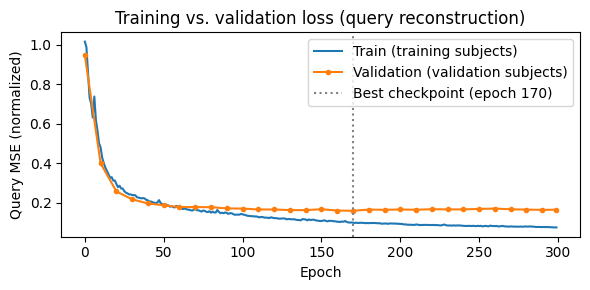

In [7]:
targets_flat = log_mag_t.reshape(n_subjects, n_dir, -1)  # [n_subj, n_dir, 2*F], normalized dB
optimizer = torch.optim.Adam(field.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
# Keras-style decay used in the original HRTF Field training script (train.py: keras_decay):
# lr_i = lr0 / (1 + decay * i), stepped once per epoch.
lr_scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, lr_lambda=lambda step: 1.0 / (1.0 + cfg["lr_decay"] * step))

eval_every = max(1, cfg["n_epochs"] // 30)
train_losses, val_losses, val_epochs = [], [], []
best_val, best_epoch, best_state = float("inf"), None, None
batch_rng = np.random.default_rng(1)
pbar = tqdm(range(cfg["n_epochs"]), desc="Training (multi-subject, latent-inferred)")
for epoch in pbar:
    epoch_loss = 0.0
    order = train_subject_idx.copy()
    batch_rng.shuffle(order)
    for batch_start in range(0, len(order), cfg["batch_size"]):
        batch = order[batch_start:batch_start + cfg["batch_size"]]
        optimizer.zero_grad()
        # Gradient-accumulate the mini-batch (each subject shares the same direction grid,
        # so this has the same effect as averaging a stacked batch loss without needing a
        # padded/masked batch tensor) -- matches the original's batch_size=18 mini-batches
        # instead of stepping after every single subject.
        for s in batch:
            loss, _, _ = subject_losses(dir_feats_t, targets_flat[s], support_idx, query_idx,
                                         create_graph=True)
            (loss / len(batch)).backward()
            epoch_loss += loss.item()
        torch.nn.utils.clip_grad_norm_(field.parameters(), max_norm=1.0)
        optimizer.step()
    epoch_loss /= len(train_subject_idx)
    train_losses.append(epoch_loss)
    lr_scheduler.step()

    if epoch % eval_every == 0 or epoch == cfg["n_epochs"] - 1:
        # Same query-loss computation as training, just on validation subjects and with no optimizer step —
        # infer_latent still needs autograd to solve for z, but that graph is discarded once we call .item().
        val_loss = np.mean([
            subject_losses(dir_feats_t, targets_flat[s], support_idx, query_idx)[0].item()
            for s in val_subject_idx
        ])
        val_losses.append(val_loss)
        val_epochs.append(epoch)
        if val_loss < best_val:
            best_val, best_epoch = val_loss, epoch
            best_state = copy.deepcopy(field.state_dict())

    if epoch % max(1, cfg["n_epochs"] // 10) == 0:
        pbar.set_postfix(loss=epoch_loss, val_loss=val_losses[-1], lr=optimizer.param_groups[0]["lr"])

field.load_state_dict(best_state)
print(f"Restored checkpoint from epoch {best_epoch} (best validation loss = {best_val:.4f})")

plt.figure(figsize=(6, 3))
plt.plot(range(cfg["n_epochs"]), train_losses, label="Train (training subjects)")
plt.plot(val_epochs, val_losses, label="Validation (validation subjects)", marker="o", markersize=3)
plt.axvline(best_epoch, color="gray", linestyle=":", label=f"Best checkpoint (epoch {best_epoch})")
plt.xlabel("Epoch"); plt.ylabel("Query MSE (normalized)")
plt.title("Training vs. validation loss (query reconstruction)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Evaluate: train vs. validation vs. test subjects

Three groups, all using the same support→infer-z→predict-query mechanism:
- **Training subjects** (20): the decoder was fitted using this subject's own query loss.
- **Validation subjects** (5): never trained on — used only to pick the best checkpoint above (selection by validation loss, not just final-epoch weights).
- **Test subjects** (5): held out entirely until this cell — the only unbiased estimate of generalization to unseen subjects.

If the field generalizes, validation and test LSD should land in the same ballpark as each other (and not too far from training LSD).

In [8]:
def evaluate_subjects(subject_idx_list, label):
    all_lsd = []
    for s in subject_idx_list:
        loss, pred, target = subject_losses(dir_feats_t, targets_flat[s], support_idx, query_idx)
        pred_db = pred.detach().cpu().numpy().reshape(-1, 2, cfg["n_freq_bins"]) * mag_std + mag_mean
        true_db = target.detach().cpu().numpy().reshape(-1, 2, cfg["n_freq_bins"]) * mag_std + mag_mean
        lsd = np.sqrt(np.mean((pred_db - true_db) ** 2, axis=-1))  # [n_query, 2], dB — standard LSD
        all_lsd.append(lsd.mean())
    all_lsd = np.array(all_lsd)
    print(f"{label}: mean LSD = {all_lsd.mean():.2f} dB over {len(subject_idx_list)} subject(s)")
    return all_lsd

train_lsd = evaluate_subjects(train_subject_idx, "Training subjects (query directions)")
val_lsd = evaluate_subjects(val_subject_idx, "Validation subjects (used for checkpoint selection)")
test_lsd = evaluate_subjects(test_subject_idx, "Test subjects (held out until now)")

Training subjects (query directions): mean LSD = 2.90 dB over 20 subject(s)
Validation subjects (used for checkpoint selection): mean LSD = 3.79 dB over 5 subject(s)
Test subjects (held out until now): mean LSD = 4.25 dB over 5 subject(s)


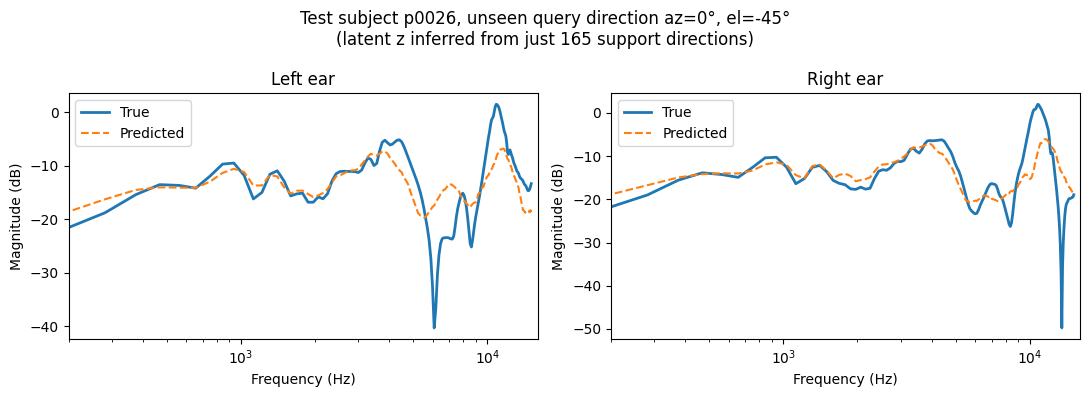

In [9]:
# Visualize one test subject: predicted vs true spectrum at a query direction
s_example = test_subject_idx[0]
_, pred, target = subject_losses(dir_feats_t, targets_flat[s_example], support_idx, query_idx)
pred_db = pred.detach().cpu().numpy().reshape(-1, 2, cfg["n_freq_bins"]) * mag_std + mag_mean
true_db = target.detach().cpu().numpy().reshape(-1, 2, cfg["n_freq_bins"]) * mag_std + mag_mean

q = 0  # first query direction
az_q, el_q, _ = positions[query_idx[q]]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ear, ax in enumerate(axes):
    ax.plot(freqs, true_db[q, ear], label="True", linewidth=2)
    ax.plot(freqs, pred_db[q, ear], label="Predicted", linestyle="--")
    ax.set_xscale("log"); ax.set_xlim(200, 16000)
    ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Magnitude (dB)")
    ax.set_title(f"{'Left' if ear == 0 else 'Right'} ear")
    ax.legend()
fig.suptitle(f"Test subject {subject_ids[s_example]}, unseen query direction az={az_q:.0f}°, el={el_q:.0f}°\n"
             f"(latent z inferred from just {n_support} support directions)")
plt.tight_layout()
plt.show()

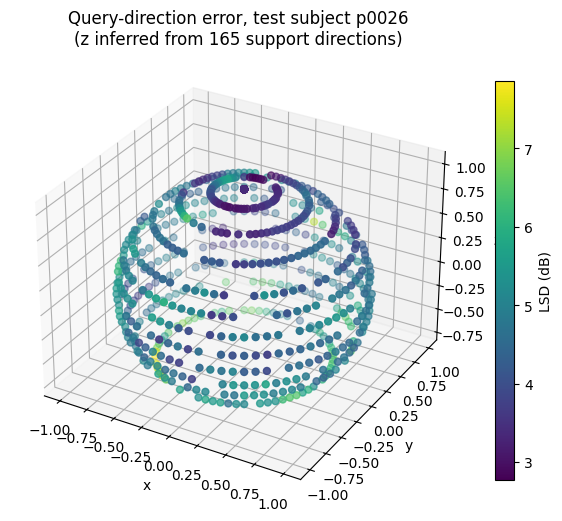

In [10]:
# Visualize error across the sphere for this subject: where does the field struggle most?
sub_lsd = np.sqrt(np.mean((pred_db - true_db) ** 2, axis=-1)).mean(axis=-1)  # [n_query], avg over ears
sub_positions = positions[query_idx]

az = np.deg2rad(sub_positions[:, 0])
el = np.deg2rad(sub_positions[:, 1])
x = np.cos(el) * np.cos(az)
y = np.cos(el) * np.sin(az)
z = np.sin(el)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(x, y, z, c=sub_lsd, cmap="viridis", s=25)
fig.colorbar(sc, ax=ax, label="LSD (dB)", shrink=0.7)
ax.set_title(f"Query-direction error, test subject {subject_ids[s_example]}\n(z inferred from {n_support} support directions)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.tight_layout()
plt.show()

## 7. Latent-space interpolation: reproducing HRTF Field Figure 4

Figure 4 / Section 4.3 of [HRTF Field (arXiv:2210.15196)](https://arxiv.org/pdf/2210.15196) is not a held-out-subject reconstruction test — it's an **unconditional latent-space interpolation** demo. The paper's procedure: train the IGON decoder on a whole dataset, infer two *training* subjects' latent codes `z1, z2` from **all** of each subject's measured directions (Eq. 3), linearly interpolate `zt = (1-t)z1 + t·z2`, decode each `zt` through the shared field, and plot the midsagittal planes of measured subject A → four synthesized interpolants (t = 0.2, 0.4, 0.6, 0.8) → measured subject B. Their finding: the spectral notches (the elevation cue) **transition smoothly** across `t` rather than jumping or collapsing, which is evidence the latent space forms a meaningful manifold rather than a lookup table — motivating latent-code interpolation as an alternative to nearest-neighbor HRTF selection for personalization.

We reproduce that structure here rather than the support-set/held-out-subject demo from Sections 5–6, with one more detail matched: the paper trains "on the entire [RIEC] dataset" for this specific demo, so this section trains its **own** dedicated field (`field_s7`) on **all 30** SONICOM subjects — no train/val/test split — separately from the `field` in Sections 5–6, which keeps its own held-out split intact for the generalization study above. `z` is inferred from each subject's **entire** grid (matching the paper's Eq. 3), and both the inner (z-inference) and outer loss use the same full direction set, matching `train.py`'s actual inner/outer loop (no support/query split here, unlike Sections 5–6). The measured endpoints and the synthesized middle panels all share the same frequency axis (`cfg["n_freq_bins"]` bins), so the comparison is apples-to-apples. `cfg["n_freq_bins"]` is set to 162 (SONICOM's `fs=48000`, so 162 bins × 93.75 Hz/bin ≈ 15.1 kHz), one bin past 15 kHz and covering the 5–11 kHz band where pinna notches are most pronounced. (Our polar-angle axis also uses a different wrap convention than the paper's 0°–180° display — ours spans the full front-to-back loop, −90° to 270° — since the exact axis definition wasn't recoverable from the paper text; the qualitative result, smooth notch transition across `t`, is what's being reproduced.)

In [11]:
## Train a dedicated field on ALL 30 subjects, matching the paper's Sec. 4.3 setup ("we train
## our model on the entire RIEC dataset") for this specific interpolation demo -- Sections 5-6
## keep their own held-out train/val/test split intact for the generalization study above.
## Also matches train.py's actual inner/outer loop: both the z-inference step and the outer
## loss are computed over the SAME full direction set (no support/query split, unlike Sections 5-6).
field_s7 = build_siren(dims_multi, cfg["w0"]).to(device)

def forward_field_s7(dirs, z):
    return field_s7(torch.cat([dirs, z], dim=-1))

def infer_latent_s7(dirs, targets, create_graph=False):
    z0 = torch.zeros(1, latent_dim, device=device, requires_grad=True)
    z0_rep = z0.repeat(dirs.shape[0], 1)
    pred = forward_field_s7(dirs, z0_rep)
    loss = nn.functional.mse_loss(pred, targets)
    grad = torch.autograd.grad(loss, [z0], create_graph=create_graph, retain_graph=create_graph)[0]
    return -grad

optimizer_s7 = torch.optim.Adam(field_s7.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
lr_scheduler_s7 = torch.optim.lr_scheduler.LambdaLR(
    optimizer_s7, lr_lambda=lambda step: 1.0 / (1.0 + cfg["lr_decay"] * step))

all_subject_idx = np.arange(n_subjects)  # all 30, no held-out split for this demo
batch_rng_s7 = np.random.default_rng(2)
pbar = tqdm(range(cfg["n_epochs"]), desc="Training field for Section 7 (all 30 subjects)")
for epoch in pbar:
    order = all_subject_idx.copy()
    batch_rng_s7.shuffle(order)
    epoch_loss = 0.0
    for batch_start in range(0, len(order), cfg["batch_size"]):
        batch = order[batch_start:batch_start + cfg["batch_size"]]
        optimizer_s7.zero_grad()
        for s in batch:
            z = infer_latent_s7(dir_feats_t, targets_flat[s], create_graph=True)
            z_rep = z.repeat(n_dir, 1)
            pred = forward_field_s7(dir_feats_t, z_rep)
            loss = nn.functional.mse_loss(pred, targets_flat[s])
            (loss / len(batch)).backward()
            epoch_loss += loss.item()
        torch.nn.utils.clip_grad_norm_(field_s7.parameters(), max_norm=1.0)
        optimizer_s7.step()
    lr_scheduler_s7.step()
    epoch_loss /= len(all_subject_idx)
    if epoch % max(1, cfg["n_epochs"] // 10) == 0:
        pbar.set_postfix(loss=epoch_loss)


Training field for Section 7 (all 30 subjects):   0%|          | 0/300 [00:00<?, ?it/s]


Training field for Section 7 (all 30 subjects):   0%|          | 0/300 [00:00<?, ?it/s, loss=1]


Training field for Section 7 (all 30 subjects):   0%|          | 1/300 [00:00<02:00,  2.47it/s, loss=1]


Training field for Section 7 (all 30 subjects):   1%|          | 2/300 [00:00<02:02,  2.44it/s, loss=1]


Training field for Section 7 (all 30 subjects):   1%|          | 3/300 [00:01<02:04,  2.39it/s, loss=1]

...


Training field for Section 7 (all 30 subjects):  99%|█████████▉| 297/300 [02:00<00:01,  2.40it/s, loss=0.073]


Training field for Section 7 (all 30 subjects):  99%|█████████▉| 298/300 [02:01<00:00,  2.44it/s, loss=0.073]


Training field for Section 7 (all 30 subjects): 100%|█████████▉| 299/300 [02:01<00:00,  2.45it/s, loss=0.073]


Training field for Section 7 (all 30 subjects): 100%|██████████| 300/300 [02:01<00:00,  2.46it/s, loss=0.073]


Training field for Section 7 (all 30 subjects): 100%|██████████| 300/300 [02:01<00:00,  2.46it/s, loss=0.073]

In [12]:
def _sagittal_polar_angle(az, el):
    """Continuous polar angle for points in the median sagittal plane (az in {0, 180}):
    below-front (-90) -> up over the top (90) -> down to below-back (270)."""
    return el - el / 90.0 * az + az


def select_midsagittal(positions):
    """Boolean mask (az in {0, 180}) + sort order by continuous polar angle."""
    mask = np.isclose(positions[:, 0], 0) | np.isclose(positions[:, 0], 180)
    order = np.argsort(_sagittal_polar_angle(positions[mask, 0], positions[mask, 1]))
    return mask, order


def midsagittal_from_db(mag_db_subject, positions, which_ear, fs, n_fft, n_bins):
    """Sagittal-plane magnitude from a [n_dir, 2, n_bins] dB-domain array
    (either the ground-truth log_mag or a field prediction, same bin layout as training)."""
    mask, order = select_midsagittal(positions)
    mag_db = mag_db_subject[mask, which_ear, :][order]
    mag = 10 ** (mag_db / 20.0)
    freqs_hz = np.fft.rfftfreq(n_fft, d=1 / fs)[:n_bins]
    polar_angles = _sagittal_polar_angle(positions[mask, 0], positions[mask, 1])[order]
    return mag, polar_angles, freqs_hz


def plot_midsagittal_plane(ax, mag_linear, polar_angles, freqs_hz, title=None, fontsize=11,
                            show_yticklabels=True, show_colorbar=True):
    """mag_linear: [n_dirs, n_bins] linear magnitude, rows already sorted by polar angle.
    polar_angles: the continuous polar angle (see _sagittal_polar_angle) for each row,
    e.g. -90 (below front) -> 90 (overhead) -> 270 (below back)."""
    mag_norm = mag_linear / mag_linear.max()
    img = ax.pcolormesh(np.log(mag_norm + 1e-8), cmap=plt.cm.viridis, vmin=-3.5, vmax=0)

    n_bins = mag_linear.shape[1]
    xtick_idx = np.linspace(0, n_bins - 1, 6).astype(int)
    ax.set_xticks(xtick_idx + 0.5)
    ax.set_xticklabels([f"{freqs_hz[i] / 1000:.1f}k" for i in xtick_idx], fontsize=fontsize)

    n_rows = mag_linear.shape[0]
    ytick_idx = np.linspace(0, n_rows - 1, min(10, n_rows)).astype(int)
    ax.set_yticks(ytick_idx + 0.5)
    if show_yticklabels:
        ax.set_yticklabels([f"{polar_angles[i]:.0f}" for i in ytick_idx], fontsize=fontsize)
        ax.set_ylabel("Polar angle (deg)", fontsize=fontsize)
    else:
        ax.set_yticklabels([])

    ax.set_xlabel("Frequency (Hz)", fontsize=fontsize)
    if title:
        ax.set_title(title, fontsize=fontsize)
    if show_colorbar:
        cbar = ax.figure.colorbar(img, ax=ax, ticks=[-3.5, -1.75, 0])
        cbar.ax.tick_params(labelsize=fontsize)
    return img

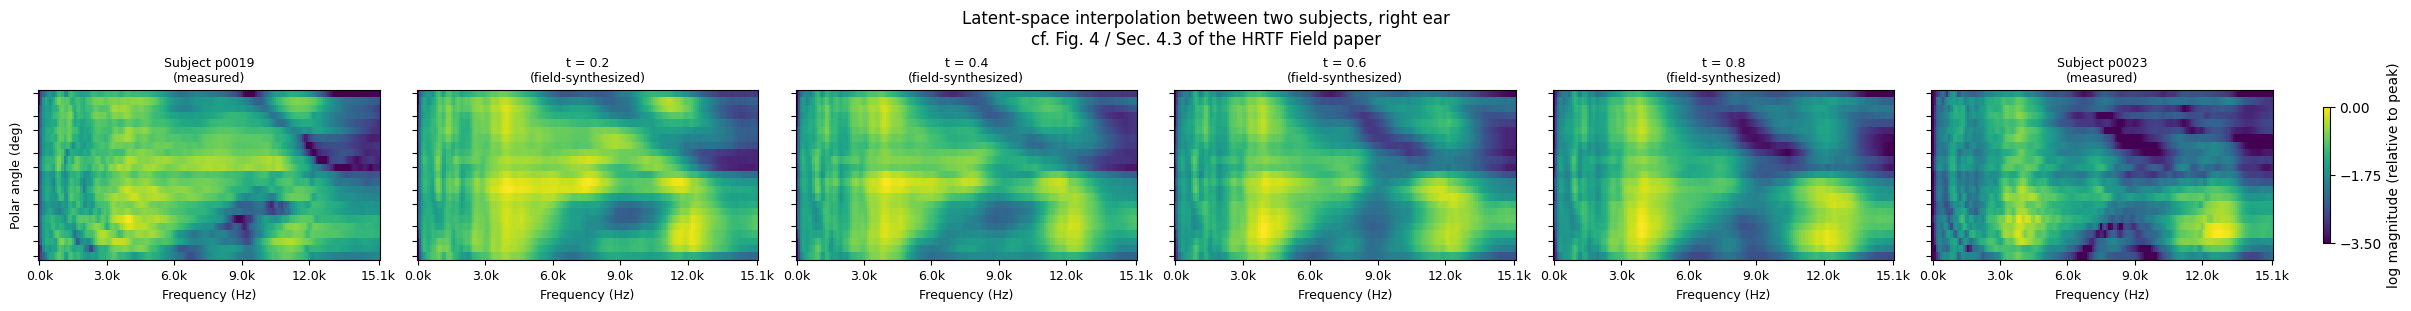

The spectral notches (dark diagonal band) should transition smoothly across t as the latent code interpolates -- evidence the learned z-space is a meaningful manifold, not just a lookup table over the training subjects.
[FAST config] all panels are capped at ~15.2 kHz; switch to FULL if the notch structure looks too faint to judge.


In [13]:
which_ear = 1  # 1 = right ear, matching the convention used in Section 6
ear_name = "right" if which_ear == 1 else "left"

subj_a, subj_b = 18, 22  # two subjects from the all-30-subject field_s7 (trained above)

z_a, z_b = infer_latent_s7(dir_feats_t, targets_flat[subj_a]), infer_latent_s7(dir_feats_t, targets_flat[subj_b])

ts = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
fig, axes = plt.subplots(1, len(ts), figsize=(4 * len(ts), 3), sharey=True, constrained_layout=True)
img = None
for i, (t, ax) in enumerate(zip(ts, axes)):
    if t == 0.0:
        mag_db = log_mag[subj_a]  # measured endpoint -- no field involved
        title = f"Subject {subject_ids[subj_a]}\n(measured)"
    elif t == 1.0:
        mag_db = log_mag[subj_b]  # measured endpoint -- no field involved
        title = f"Subject {subject_ids[subj_b]}\n(measured)"
    else:
        z_t = (1 - t) * z_a + t * z_b
        z_t_rep = z_t.repeat(dir_feats_t.shape[0], 1)
        with torch.no_grad():
            mag_db = (forward_field_s7(dir_feats_t, z_t_rep).cpu().numpy().reshape(n_dir, 2, cfg["n_freq_bins"])
                       * mag_std + mag_mean)
        title = f"t = {t:.1f}\n(field-synthesized)"

    mag, polar_angles, freqs_hz = midsagittal_from_db(mag_db, positions, which_ear, fs,
                                                        n_fft=512, n_bins=cfg["n_freq_bins"])
    img = plot_midsagittal_plane(ax, mag, polar_angles, freqs_hz, title=title, fontsize=9,
                                  show_yticklabels=(i == 0), show_colorbar=False)

cbar = fig.colorbar(img, ax=axes, ticks=[-3.5, -1.75, 0], shrink=0.8, pad=0.015)
cbar.set_label("log magnitude (relative to peak)")
fig.suptitle(f"Latent-space interpolation between two subjects, {ear_name} ear\n"
             f"cf. Fig. 4 / Sec. 4.3 of the HRTF Field paper")
plt.show()

max_freq_khz = cfg["n_freq_bins"] * (fs / 512) / 1000
print("The spectral notches (dark diagonal band) should transition smoothly across t as the "
      "latent code interpolates -- evidence the learned z-space is a meaningful manifold, "
      "not just a lookup table over the training subjects.")
print(f"[{ACTIVE_CONFIG} config] all panels are capped at ~{max_freq_khz:.1f} kHz; "
      "switch to FULL if the notch structure looks too faint to judge.")

## Recap

- A SIREN (matching HRTF Field's real architecture) can represent one subject's full HRTF as a continuous field
- Sharing a decoder across subjects, with **latent codes inferred by a single gradient step** rather than a lookup table, generalizes to genuinely unseen subjects from just a small support set — no separate encoder network required
- We used a proper subject-level train/validation/test split (20/5/5 of the 30 real SONICOM subjects): validation picked the best checkpoint during training, and test subjects were never touched until the final evaluation
- We trained in the **dB domain** (equivalent to NIIRF/RANF's LSD loss), for consistency with the rest of this tutorial

**Next:** `02_niirf_filter_field.ipynb` swaps the decoder's output for an interpretable DSP filter cascade. `03_upsampling_ranf.ipynb` then replaces the single-gradient-step latent with retrieval augmentation across the subject pool.